## DAMATH DYNA-Q

In [84]:
%pip install numpy matplotlib torch

Note: you may need to restart the kernel to use updated packages.


In [85]:
# Imports
import torch
import copy
import random
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt


In [86]:
# Auto-select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Class Environment of Damath

### Damath Board and Operations

In [87]:
import torch

class DamathEnvironment: 
    def __init__(self, device='cpu'):
        self.device = device
        self.board = torch.zeros((8, 8), dtype=torch.int32, device=self.device)
        self.board_size = 8
        self.EMPTY_SQUARE = 999.0

        # Official Damath board - BOTH PLAYERS HAVE SAME PIECE VALUES
        # Ownership determined by position ONLY (like checkers)
        # Blue pieces (top, rows 0-2) = Player 2 = -1
        # Red pieces (bottom, rows 5-7) = Player 1 = +1
        self.initial_board_template = [
            [2, "#", -5, "#", 8, "#", -11, "#"],      # Row 0: Player 2 (blue)
            ["#", -7, "#", 10, "#", -3, "#", 0],      # Row 1: Player 2 (blue)
            [4, "#", -1, "#", 6, "#", -9, "#"],       # Row 2: Player 2 (blue)
            ["#", "#", "#", "#", "#", "#", "#", "#"], # Empty
            ["#", "#", "#", "#", "#", "#", "#", "#"], # Empty
            ["#", -9, "#", 6, "#", -1, "#", 4],       # Row 5: Player 1 (red)
            [0, "#", -3, "#", 10, "#", -7, "#"],      # Row 6: Player 1 (red)
            ["#", -11, "#", 8, "#", -5, "#", 2]       # Row 7: Player 1 (red)
        ]

        # Convert to tensor
        board_values = []
        for row in self.initial_board_template:
            tensor_row = []
            for cell in row:
                if cell == "#":
                    tensor_row.append(self.EMPTY_SQUARE)
                elif cell == "0":
                    tensor_row.append(0.0)
                else:
                    tensor_row.append(float(cell))
            board_values.append(tensor_row)

        self.initial_board = torch.tensor(board_values, dtype=torch.float32, device=device)

        # Operations board
        self.operations_board = [
            ["+", "#", "÷", "#", "-", "#", "×", "#"],
            ["#", "×", "#", "+", "#", "÷", "#", "-"],
            ["-", "#", "+", "#", "÷", "#", "×", "#"],
            ["#", "÷", "#", "-", "#", "×", "#", "+"],
            ["×", "#", "÷", "#", "-", "#", "+", "#"],
            ["#", "+", "#", "÷", "#", "-", "#", "×"],
            ["÷", "#", "×", "#", "+", "#", "-", "#"],
            ["#", "-", "#", "×", "#", "+", "#", "÷"],
        ]
        
        self.consecutive_non_capture_moves = 0
        self.max_non_capture_moves = 20

        # CRITICAL: Track piece ownership by BOARD POSITION (not value!)
        # This is the ONLY way to distinguish same-valued pieces
        self.piece_positions = {}  # {(row, col): player_owner}
        
        self.reset()
    
    def _initialize_piece_ownership(self):
        """
        CHECKERS RULE: Ownership by starting position ONLY.
        Both players have identical piece values!
        """
        self.piece_positions.clear()
        
        for r in range(self.board_size):
            for c in range(self.board_size):
                val = self.board[r, c].item()
                if val != self.EMPTY_SQUARE:
                    # Assign ownership purely by row position
                    if r <= 2:  # Top 3 rows = Player 2
                        self.piece_positions[(r, c)] = -1
                    elif r >= 5:  # Bottom 3 rows = Player 1
                        self.piece_positions[(r, c)] = 1
    
    def _get_piece_owner(self, row, col):
        """Get owner by position tracking"""
        return self.piece_positions.get((row, col), 0)
    
    def _is_opponent_piece(self, my_row, my_col, other_row, other_col):
        """
        CHECKERS-STYLE: Check if pieces belong to different players
        by tracking their positions.
        """
        if self.board[other_row, other_col].item() == self.EMPTY_SQUARE:
            return False
        
        my_owner = self._get_piece_owner(my_row, my_col)
        other_owner = self._get_piece_owner(other_row, other_col)
        
        # Different owners = opponent (both must be valid pieces)
        return my_owner != other_owner and my_owner != 0 and other_owner != 0
    
    def _is_own_piece(self, my_row, my_col, target_row, target_col):
        """Check if pieces belong to same player"""
        if self.board[target_row, target_col].item() == self.EMPTY_SQUARE:
            return False
        
        my_owner = self._get_piece_owner(my_row, my_col)
        target_owner = self._get_piece_owner(target_row, target_col)
        
        return my_owner == target_owner and my_owner != 0
    
    def _move_piece(self, from_r, from_c, to_r, to_c):
        """Update position tracking when piece moves"""
        if (from_r, from_c) in self.piece_positions:
            owner = self.piece_positions.pop((from_r, from_c))
            self.piece_positions[(to_r, to_c)] = owner
        
    def _is_valid_coord(self, r, c):
        return 0 <= r < self.board_size and 0 <= c < self.board_size

    def _apply_operation(self, piece_value, captured_value, op_symbol):
        piece_abs = abs(piece_value)
        captured_abs = abs(captured_value)
        
        piece_is_dama = piece_abs > 12.0
        captured_is_dama = captured_abs > 12.0
        
        piece_base = piece_abs - 12.0 if piece_is_dama else piece_abs
        captured_base = captured_abs - 12.0 if captured_is_dama else captured_abs
        
        base_score = 0.0
        if op_symbol == "÷":
            base_score = 0.0 if captured_base == 0 else piece_base / captured_base
        elif op_symbol == "-":
            base_score = piece_base - captured_base
        elif op_symbol == "+":
            base_score = piece_base + captured_base
        elif op_symbol == "×":
            base_score = piece_base * captured_base
        
        if piece_is_dama and captured_is_dama:
            base_score *= 2.0
        elif piece_is_dama or captured_is_dama:
            base_score *= 1.5
        
        return round(abs(base_score), 1)

    def get_valid_moves(self, pos):
        r, c = pos
        piece = self.board[r, c].item()
        if piece == self.EMPTY_SQUARE or self.operations_board[r][c] == "#":
            return []
        
        moves = []
        is_king = abs(piece) > 12
        
        # Determine movement direction based on position owner
        piece_owner = self._get_piece_owner(r, c)
        
        if is_king:
            directions = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif piece_owner == 1:  # Player 1 moves up
            directions = [(-1, -1), (-1, 1)]
        else:  # Player 2 moves down
            directions = [(1, -1), (1, 1)]

        # Simple moves
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if self._is_valid_coord(nr, nc) and self.board[nr, nc].item() == self.EMPTY_SQUARE:
                op_symbol = self.operations_board[nr][nc]
                if op_symbol != "#":
                    promoted = (piece_owner == 1 and nr == 0 and not is_king) or \
                               (piece_owner == -1 and nr == self.board_size - 1 and not is_king)
                    moves.append((nr, nc, op_symbol, [], promoted))

        # Jumps
        for dr, dc in directions:
            jr, jc = r + 2 * dr, c + 2 * dc
            mid_r, mid_c = r + dr, c + dc
            
            if not is_king:
                if (self._is_valid_coord(jr, jc) and
                    self._is_valid_coord(mid_r, mid_c) and
                    self.board[jr, jc].item() == self.EMPTY_SQUARE and
                    self.operations_board[jr][jc] != "#"):
                    
                    # CRITICAL: Check opponent by POSITION, not value
                    if (self.board[mid_r, mid_c].item() != self.EMPTY_SQUARE and 
                        self._is_opponent_piece(r, c, mid_r, mid_c)):
                        op_symbol = self.operations_board[jr][jc]
                        promoted = (piece_owner == 1 and jr == 0) or \
                                   (piece_owner == -1 and jr == self.board_size - 1)
                        moves.append((jr, jc, op_symbol, [(mid_r, mid_c)], promoted))
            else:
                moves.extend(self._get_king_jumps(r, c, dr, dc))
        
        jumps = [move for move in moves if move[3]]
        return jumps if jumps else moves

    def _get_king_jumps(self, r, c, dr, dc):
        """King jumps with position-based opponent validation"""
        jumps = []
        captured_pos = None
        for i in range(1, self.board_size):
            pr, pc = r + i * dr, c + i * dc
            if not self._is_valid_coord(pr, pc):
                break
            current_square = self.board[pr, pc].item()
            if captured_pos is None:
                if self._is_opponent_piece(r, c, pr, pc):
                    captured_pos = (pr, pc)
                elif self._is_own_piece(r, c, pr, pc):
                    break
            else:
                if current_square == self.EMPTY_SQUARE and self.operations_board[pr][pc] != "#":
                    op_symbol = self.operations_board[pr][pc]
                    jumps.append((pr, pc, op_symbol, [captured_pos], False))
                elif current_square != self.EMPTY_SQUARE:
                    break
        return jumps

    def get_all_valid_actions(self):
        all_actions = []
        jumps_available = []
        for r in range(self.board_size):
            for c in range(self.board_size):
                piece = self.board[r, c].item()
                if piece == self.EMPTY_SQUARE:
                    continue
                
                # Check if piece belongs to current player BY POSITION
                piece_owner = self._get_piece_owner(r, c)
                if piece_owner == self.current_player:
                    moves = self.get_valid_moves((r, c))
                    for move in moves:
                        to_r, to_c, op_symbol, captured, promoted = move
                        action = ((r, c), (to_r, to_c), op_symbol, captured, promoted)
                        if captured:
                            jumps_available.append(action)
                        else:
                            all_actions.append(action)
        
        if jumps_available:
            max_captures = max(len(a[3]) for a in jumps_available)
            best_jumps = [a for a in jumps_available if len(a[3]) == max_captures]
            dama_jumps, regular_jumps = [], []
            for a in best_jumps:
                from_r, from_c = a[0]
                piece = self.board[from_r, from_c].item()
                if abs(piece) > 12.0:
                    dama_jumps.append(a)
                else:
                    regular_jumps.append(a)
            return dama_jumps + regular_jumps if dama_jumps else best_jumps
        return all_actions

    def step(self, action):
        """Apply move with position-based ownership validation"""
        self.done = False
        (from_pos, to_pos, op_symbol, captured, promoted) = action
        from_r, from_c = from_pos
        to_r, to_c = to_pos
        piece = self.board[from_r, from_c].item()
        reward = 0.0
        is_capture = bool(captured)
        self.last_move_info = ""

        # Capture validation and execution
        if is_capture:
            cr, cc = captured[0]
            captured_piece_value = self.board[cr, cc].item()

            # Validate opponent BY POSITION
            if not self._is_opponent_piece(from_r, from_c, cr, cc):
                my_owner = self._get_piece_owner(from_r, from_c)
                cap_owner = self._get_piece_owner(cr, cc)
                print(f"⚠️ INVALID CAPTURE BLOCKED!")
                print(f"   Piece at ({from_r},{from_c}) [Player {my_owner}] value={piece:+.0f}")
                print(f"   Tried to capture ({cr},{cc}) [Player {cap_owner}] value={captured_piece_value:+.0f}")
                return self.board.clone(), -10.0, False

            # Valid capture
            reward = self._apply_operation(piece, captured_piece_value, op_symbol)
            self.consecutive_non_capture_moves = 0

            # Remove captured piece from board AND position tracking
            for (cr, cc) in captured:
                self.board[cr, cc] = self.EMPTY_SQUARE
                if (cr, cc) in self.piece_positions:
                    del self.piece_positions[(cr, cc)]

            player_name = "Player 1 (Red)" if self.current_player > 0 else "Player 2 (Blue)"
            piece_base = piece if abs(piece) <= 12 else (piece - 12 if piece > 0 else piece + 12)
            cap_base = captured_piece_value if abs(captured_piece_value) <= 12 else \
                       (captured_piece_value - 12 if captured_piece_value > 0 else captured_piece_value + 12)
            
            self.last_move_info = (
                f"{player_name} ({piece_base:+.0f}) at ({from_r},{from_c}) captures "
                f"({cap_base:+.0f}) at ({cr},{cc}) using {op_symbol} → +{reward} points!"
            )
        else:
            self.consecutive_non_capture_moves += 1
            self.last_move_info = "No capture — no points scored."

        # Move piece on board
        self.board[from_r, from_c] = self.EMPTY_SQUARE
        self.board[to_r, to_c] = piece
        
        # Update position tracking
        self._move_piece(from_r, from_c, to_r, to_c)

        # Handle promotion
        if promoted:
            new_value = abs(piece) + 12.0
            if piece < 0:
                new_value = -new_value
            self.board[to_r, to_c] = new_value
            reward += 1.0
            self.last_move_info += " 👑 PROMOTED TO DAMA!"

        reward = round(reward, 1)
        self.scores[self.current_player] = round(self.scores[self.current_player] + reward, 1)
        self.current_player *= -1

        next_actions = self.get_all_valid_actions()
        if not next_actions or self._check_draw_conditions() or \
           self.consecutive_non_capture_moves >= self.max_non_capture_moves:
            self.done = True

        return self.board.clone(), reward, self.done

    def _check_draw_conditions(self):
        player1_pieces = player2_pieces = 0
        player1_kings = player2_kings = 0
        for r in range(self.board_size):
            for c in range(self.board_size):
                val = self.board[r, c].item()
                if val == self.EMPTY_SQUARE: 
                    continue
                owner = self._get_piece_owner(r, c)
                if owner == 1:
                    player1_pieces += 1
                    if abs(val) > 12: 
                        player1_kings += 1
                elif owner == -1:
                    player2_pieces += 1
                    if abs(val) > 12: 
                        player2_kings += 1
        
        if player1_pieces == 1 and player2_pieces == 1:
            return True
        if (player1_kings == 2 and player2_kings == 1 and player1_pieces == 2 and player2_pieces == 1) or \
           (player1_kings == 1 and player2_kings == 2 and player1_pieces == 1 and player2_pieces == 2):
            if not any(a[3] for a in self.get_all_valid_actions()):
                return True
        return False

    def calculate_final_scores(self):
        final_scores = self.scores.copy()
        
        if final_scores[1] > final_scores[-1]:
            winner = 1
        elif final_scores[-1] > final_scores[1]:
            winner = -1
        else:
            winner = 0
            
        if winner != 0:
            final_scores[winner] = round(final_scores[winner] + 5.0, 1)
            final_scores[-winner] = round(final_scores[-winner] - 2.0, 1)
        
        return final_scores

    def reset(self):
        self.board = self.initial_board.clone()
        self.current_player = 1
        self.scores = {1: 0.0, -1: 0.0}
        self.consecutive_non_capture_moves = 0
        self.done = False
        self.last_move_info = ""
        self._initialize_piece_ownership()
        return self._get_state()

    def _get_state(self):
        return self.board.clone()

    def render_board(self):
        board_str = []
        for r in range(self.board_size):
            row_str = []
            for c in range(self.board_size):
                if self.operations_board[r][c] == "#":
                    row_str.append("  #  ")
                    continue
                val = self.board[r, c].item()
                if val == self.EMPTY_SQUARE:
                    row_str.append("  .  ")
                else:
                    is_king = abs(val) > 12.0
                    display_val = int(abs(val)) if not is_king else int(abs(val) - 12)
                    prefix = "K" if is_king else ""
                    sign = "+" if val >= 0 else "-"
                    
                    # Show ownership by position
                    owner = self._get_piece_owner(r, c)
                    owner_mark = "🔴" if owner == 1 else "🔵" if owner == -1 else "?"
                    
                    row_str.append(f"{sign}{prefix}{display_val:02d}{owner_mark}")
            board_str.append(" ".join(row_str))
        
        print("\n" + "\n".join(board_str))
        p1_score = round(self.scores[1], 1)
        p2_score = round(self.scores[-1], 1)
        print(f"\n🔴 Player 1 (Red): {p1_score}  |  🔵 Player 2 (Blue): {p2_score}")
        if self.last_move_info:
            print("➡️ ", self.last_move_info)

    def determine_winner(self):
        final_scores = self.calculate_final_scores()
        if final_scores[1] > final_scores[-1]:
            winner = 1
        elif final_scores[-1] > final_scores[1]:
            winner = -1
        else:
            winner = 0
        return winner, final_scores

    def parse_move(self, from_r, from_c, to_r, to_c):
        op_symbol = None
        if self._is_valid_coord(to_r, to_c):
            op = self.operations_board[to_r][to_c]
            op_symbol = op if op != "#" else None
        
        captured = []
        dr, dc = to_r - from_r, to_c - from_c
        if abs(dr) == 2 and abs(dc) == 2:
            mid_r, mid_c = from_r + dr // 2, from_c + dc // 2
            if self._is_valid_coord(mid_r, mid_c):
                if self.board[mid_r, mid_c].item() != self.EMPTY_SQUARE:
                    captured.append((mid_r, mid_c))
        
        promoted = False
        piece = self.board[from_r, from_c].item()
        if piece != self.EMPTY_SQUARE:
            piece_owner = self._get_piece_owner(from_r, from_c)
            is_king = abs(piece) > 12.0
            if not is_king:
                if (piece_owner == 1 and to_r == 0) or \
                   (piece_owner == -1 and to_r == self.board_size - 1):
                    promoted = True
        
        return (from_r, from_c), (to_r, to_c), op_symbol, captured, promoted

    def evaluate_action(self, action):
        """Evaluate action quality for AI"""
        (from_r, from_c), (to_r, to_c), op_symbol, captured, promoted = action
        score = 0.0
        
        piece = self.board[from_r, from_c].item()
        
        # Capturing is valuable
        if captured:
            cr, cc = captured[0]
            captured_piece = self.board[cr, cc].item()
            potential_reward = self._apply_operation(piece, captured_piece, op_symbol)
            score += potential_reward * 10
            
            captured_abs = abs(captured_piece)
            if captured_abs > 12:
                captured_abs -= 12
            score += captured_abs * 2
            
            if abs(captured_piece) > 12:
                score += 20
        
        # Promotion bonus
        if promoted:
            score += 50
        
        # Positional scoring
        piece_owner = self._get_piece_owner(from_r, from_c)
        if piece_owner == 1:
            score += (7 - to_r) * 2
        else:
            score += to_r * 2
        
        # Center control
        center_distance = abs(to_c - 3.5)
        score += (3.5 - center_distance) * 1
        
        # Avoid edges
        if to_c == 0 or to_c == 7:
            score -= 5
        
        # Operation preference
        if op_symbol == "×":
            score += 3
        elif op_symbol == "+":
            score += 2
        elif op_symbol == "÷":
            score += 1
        
        return score

    def get_best_action(self, valid_actions):
        """Choose best action using heuristics"""
        if not valid_actions:
            return None
        
        action_scores = [(action, self.evaluate_action(action)) for action in valid_actions]
        action_scores.sort(key=lambda x: x[1], reverse=True)
        
        return action_scores[0][0]

## Damath Agent

In [88]:
import numpy as np
import random
import torch # Import if not already done in the environment
# import matplotlib.pyplot as plt # Assuming this is available in the global scope

class DynaQAgent:
    def __init__(self, planning_steps=30, alpha=0.05, gamma=0.9, epsilon=0.2):
        self.q_table = {}
        self.model = {}
        self.planning_steps = planning_steps
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_start = epsilon
        self.epsilon_end = 0.01
        self.epsilon_decay = 0.995
        self.epsilon = epsilon
        
    def decay_epsilon(self):
        """Gradually reduce exploration as training progresses"""
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def _action_to_hashable(self, action):
        """Converts complex action tuples (like (r, c, move)) into hashable format for Q-table."""
        if action is None:
            return None

        # Case 1: New format from get_all_valid_actions() → (from_r, from_c, move)
        if isinstance(action, tuple) and len(action) == 3 and isinstance(action[2], tuple):
            from_r, from_c, move = action
            if len(move) >= 2:
                to_r, to_c = move[0], move[1]
                captured = tuple(move[3]) if len(move) > 3 and move[3] else ()
                promoted = bool(move[4]) if len(move) > 4 else False
                return ((from_r, from_c), (to_r, to_c), None, captured, promoted)

        # Case 2: Old format (already expanded tuple)
        if len(action) == 5:
            (from_pos, to_pos, op_symbol, captured, promoted) = action
            captured_tuple = tuple(captured) if captured else ()
            return (from_pos, to_pos, op_symbol, captured_tuple, promoted)

        # Case 3: Fallback for safety
        return tuple(action)

    def _state_to_hashable(self, state_tensor):
        """Converts the board tensor state to a hashable tuple of integers."""
        # Convert tensor to a flat list of integers, then to a tuple.
        # It's crucial to cast to int/float and remove torch tensor properties.
        # We need to explicitly handle the float values (like 999.0) by rounding or casting.
        return tuple(int(x) if x == self.EMPTY_SQUARE or abs(x) >= 12 else round(x) for x in state_tensor.flatten().tolist())

    def choose_action(self, state_hash, valid_actions):
        """
        Choose an action using epsilon-greedy policy.
        Supports both (r, c, move) and legacy action formats.
        """
        if not valid_actions:
            return None

        # Convert to hashable form for Q lookup
        hashable_actions = [self._action_to_hashable(a) for a in valid_actions]

        # --- ε-greedy exploration ---
        if np.random.rand() < self.epsilon:
            return random.choice(valid_actions)

        # --- Exploitation ---
        q_vals = [self.q_table.get((state_hash, ha), 0.0) for ha in hashable_actions]
        max_q = np.max(q_vals)
        best_indices = [i for i, q in enumerate(q_vals) if q == max_q]

        return valid_actions[random.choice(best_indices)]

    def learn(self, state_hash, action, reward, next_state_hash, next_actions):
        """Update Q from real experience + planning steps."""
        ha = self._action_to_hashable(action)

        # --- 1. Q-learning update (real experience)
        old_q = self.q_table.get((state_hash, ha), 0)
        
        # Calculate max Q for the next state
        next_q = 0
        if next_actions:
            # CRITICAL FIX: Only check Q-values for the actual valid *next* actions (for the opposing player)
            hashable_next = [self._action_to_hashable(a) for a in next_actions]
            next_q = max([self.q_table.get((next_state_hash, h), 0) for h in hashable_next], default=0)
            
        new_q = old_q + self.alpha * (reward + self.gamma * next_q - old_q)
        self.q_table[(state_hash, ha)] = new_q

        # --- 2. Store in model
        # Store (reward, next_state) for the action taken from the current state.
        self.model[(state_hash, ha)] = (reward, next_state_hash)

        # --- 3. Planning (sample from model)
        if not self.model: # Avoid error if model is empty (first step)
            return

        for _ in range(self.planning_steps):
            # Sample (state, action) from model's keys
            (s, a), (r, s_next) = random.choice(list(self.model.items()))
            
            old_q = self.q_table.get((s, a), 0)

            # CRITICAL FIX: Estimate best next action value based ONLY on model-sampled next state (s_next)
            # Find all known hashable actions (h) for the next state (s_next) in the Q-table.
            # This is inefficient, but necessary for the Dyna-Q tabular approach.
            next_actions_in_q = [h for (state_key, h) in self.q_table.keys() if state_key == s_next]
            
            q_next = max([self.q_table.get((s_next, h), 0) for h in next_actions_in_q], default=0)

            new_q = old_q + self.alpha * (r + self.gamma * q_next - old_q)
            self.q_table[(s, a)] = new_q

## Training Loop

🎮 Starting Dyna-Q Training for 6000 episodes...
Episode 100/6000
  Avg Reward: 249.80 | Avg Steps: 54.7
  P1: 50 | P2: 50 | Draw: 0
  Epsilon: 0.3805 | Q-table: 4715
----------------------------------------------------------------------
Episode 200/6000
  Avg Reward: 259.08 | Avg Steps: 56.5
  P1: 50 | P2: 50 | Draw: 0
  Epsilon: 0.3619 | Q-table: 9463
----------------------------------------------------------------------
Episode 300/6000
  Avg Reward: 252.95 | Avg Steps: 55.7
  P1: 44 | P2: 55 | Draw: 0
  Epsilon: 0.3443 | Q-table: 14087
----------------------------------------------------------------------
Episode 400/6000
  Avg Reward: 242.30 | Avg Steps: 53.8
  P1: 51 | P2: 48 | Draw: 1
  Epsilon: 0.3275 | Q-table: 18401
----------------------------------------------------------------------
Episode 500/6000
  Avg Reward: 258.67 | Avg Steps: 55.3
  P1: 49 | P2: 51 | Draw: 0
  Epsilon: 0.3115 | Q-table: 22847
----------------------------------------------------------------------
Epis

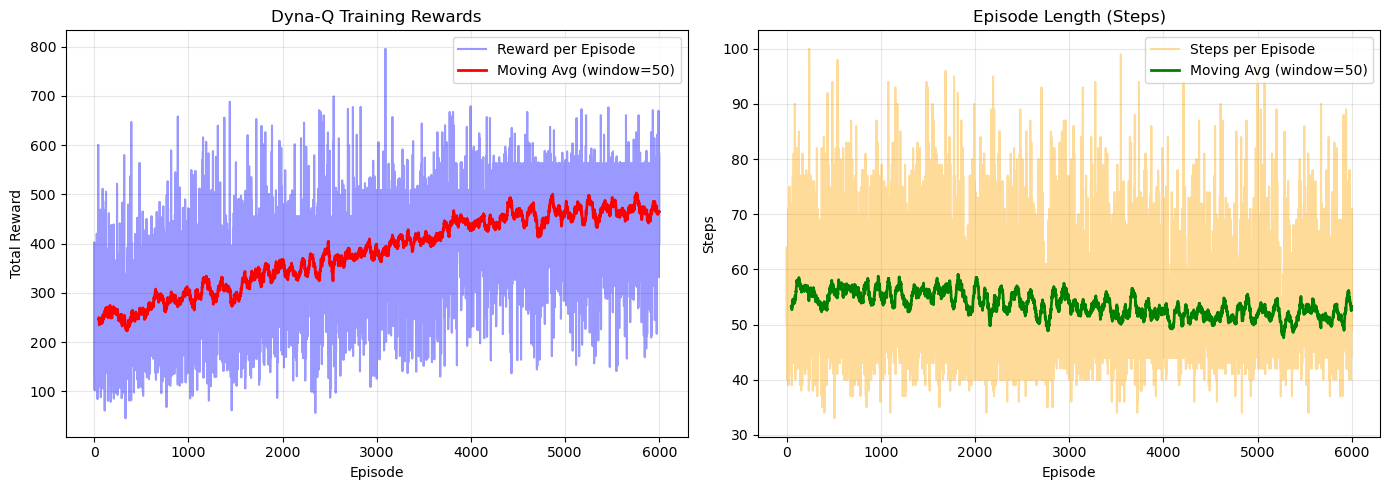

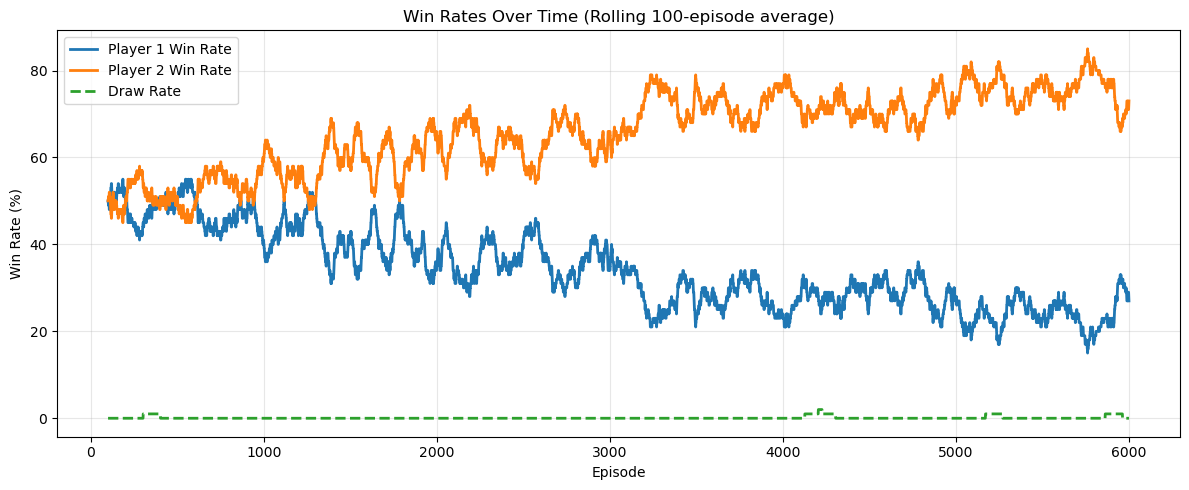


🎮 Demo Game with Trained Agent:

+02🔵   #   -05🔵   #   +08🔵   #   -11🔵   #  
  #   -07🔵   #   +10🔵   #   -03🔵   #   +00🔵
+04🔵   #   -01🔵   #   +06🔵   #   -09🔵   #  
  #     .     #     .     #     .     #     .  
  .     #     .     #     .     #     .     #  
  #   -09🔴   #   +06🔴   #   -01🔴   #   +04🔴
+00🔴   #   -03🔴   #   +10🔴   #   -07🔴   #  
  #   -11🔴   #   +08🔴   #   -05🔴   #   +02🔴

🔴 Player 1 (Red): 0.0  |  🔵 Player 2 (Blue): 0.0

Step 1 | Player 1:
   From (5,1) → To (4,2)
   Reward: 0.0 | Score: 0.0

+02🔵   #   -05🔵   #   +08🔵   #   -11🔵   #  
  #   -07🔵   #   +10🔵   #   -03🔵   #   +00🔵
+04🔵   #   -01🔵   #   +06🔵   #   -09🔵   #  
  #     .     #     .     #     .     #     .  
  .     #   -09🔴   #     .     #     .     #  
  #     .     #   +06🔴   #   -01🔴   #   +04🔴
+00🔴   #   -03🔴   #   +10🔴   #   -07🔴   #  
  #   -11🔴   #   +08🔴   #   -05🔴   #   +02🔴

🔴 Player 1 (Red): 0.0  |  🔵 Player 2 (Blue): 0.0
➡️  No capture — no points scored.

Step 2 | Player 2:
   From (2,4) → T

In [89]:
import random
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

class DynaQAgent:
    def __init__(self, 
                 learning_rate=0.2,         # Increased for faster learning
                 discount_factor=0.95,      # Look ahead more
                 epsilon=0.4,               # Start with more exploration
                 epsilon_decay=0.9995,      # Slower decay
                 epsilon_min=0.05,          # Keep some exploration
                 planning_steps=50):        # Dyna-Q planning
        
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.planning_steps = planning_steps
        
        # Q-table: {state_hash: {action_key: q_value}}
        self.q_table = defaultdict(lambda: defaultdict(float))
        
        # Model for Dyna-Q: {(state, action): (reward, next_state, done)}
        self.model = {}
        
        # Track visited state-action pairs for planning
        self.state_actions = []
        
        self.EMPTY_SQUARE = 999.0
        
    def _state_to_hashable(self, state_tensor):
        """Convert board state tensor to hashable string"""
        return str(state_tensor.flatten().tolist())
    
    def _action_to_key(self, action):
        """Convert action tuple to hashable key"""
        (from_pos, to_pos, op_symbol, captured, promoted) = action
        return (from_pos, to_pos, op_symbol, tuple(captured) if captured else (), promoted)
    
    def choose_action(self, state_hash, valid_actions):
        """Epsilon-greedy action selection"""
        if not valid_actions:
            return None
        
        # Exploration
        if random.random() < self.epsilon:
            return random.choice(valid_actions)
        
        # Exploitation - choose best action based on Q-values
        best_value = float('-inf')
        best_actions = []
        
        for action in valid_actions:
            action_key = self._action_to_key(action)
            q_value = self.q_table[state_hash][action_key]
            
            # Add small bonus for capturing moves if Q-values are equal
            (_, _, _, captured, promoted) = action
            bonus = 0
            if captured:
                bonus = 0.5  # Prefer captures
            if promoted:
                bonus += 0.3  # Prefer promotions
            
            total_value = q_value + bonus
            
            if total_value > best_value:
                best_value = total_value
                best_actions = [action]
            elif total_value == best_value:
                best_actions.append(action)
        
        return random.choice(best_actions)
    
    def learn(self, state_hash, action, reward, next_state_hash, next_valid_actions):
        """Q-learning update with Dyna-Q planning"""
        action_key = self._action_to_key(action)
        
        # Current Q-value
        current_q = self.q_table[state_hash][action_key]
        
        # Calculate max Q-value for next state
        if not next_valid_actions:
            max_next_q = 0
        else:
            max_next_q = max(
                self.q_table[next_state_hash][self._action_to_key(a)]
                for a in next_valid_actions
            )
        
        # Q-learning update
        td_target = reward + self.gamma * max_next_q
        td_error = td_target - current_q
        new_q = current_q + self.lr * td_error
        
        self.q_table[state_hash][action_key] = new_q
        
        # Store in model for Dyna-Q planning
        self.model[(state_hash, action_key)] = (reward, next_state_hash, next_valid_actions)
        
        # Track state-action pair
        if (state_hash, action_key) not in self.state_actions:
            self.state_actions.append((state_hash, action_key))
        
        # Dyna-Q Planning: Simulate experiences
        self._plan()
    
    def _plan(self):
        """Dyna-Q planning step - replay past experiences"""
        if not self.state_actions:
            return
        
        for _ in range(self.planning_steps):
            # Sample random state-action pair
            state_hash, action_key = random.choice(self.state_actions)
            
            if (state_hash, action_key) not in self.model:
                continue
            
            # Get stored experience
            reward, next_state_hash, next_valid_actions = self.model[(state_hash, action_key)]
            
            # Q-learning update on simulated experience
            current_q = self.q_table[state_hash][action_key]
            
            if not next_valid_actions:
                max_next_q = 0
            else:
                max_next_q = max(
                    self.q_table[next_state_hash][self._action_to_key(a)]
                    for a in next_valid_actions
                )
            
            td_target = reward + self.gamma * max_next_q
            td_error = td_target - current_q
            new_q = current_q + self.lr * td_error
            
            self.q_table[state_hash][action_key] = new_q
    
    def decay_epsilon(self):
        """Decay exploration rate"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


def train_dyna_q_agent(env, agent, episodes=6000, MAX_STEPS=100, verbose_interval=100):
    """
    Train Dyna-Q agent with proper self-play.
    """
    rewards_per_episode = []
    steps_per_episode = []
    p1_wins = []
    p2_wins = []
    draws = []
    
    def get_state_hash(state_tensor):
        return agent._state_to_hashable(state_tensor)
    
    print(f"🎮 Starting Dyna-Q Training for {episodes} episodes...")
    print("=" * 70)
    
    for ep in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0
        steps = 0
        
        while not done and steps < MAX_STEPS:
            current_state_hash = get_state_hash(state)
            
            # Get valid actions for current player
            valid_actions = env.get_all_valid_actions()
            
            if not valid_actions:
                done = True
                break
            
            # Choose action
            action = agent.choose_action(current_state_hash, valid_actions)
            
            if not action:
                done = True
                break
            
            # Take action
            next_state, reward, done = env.step(action)
            next_state_hash = get_state_hash(next_state)
            
            # Get next valid actions (for opponent)
            next_valid_actions = env.get_all_valid_actions()
            
            # Learn from this transition
            agent.learn(current_state_hash, action, reward, next_state_hash, next_valid_actions)
            
            total_reward += reward
            steps += 1
            state = next_state
        
        # Decay epsilon after each episode
        agent.decay_epsilon()
        
        # Record statistics
        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)
        
        # Track wins
        if done:
            winner, _ = env.determine_winner()
            p1_wins.append(1 if winner == 1 else 0)
            p2_wins.append(1 if winner == -1 else 0)
            draws.append(1 if winner == 0 else 0)
        else:
            p1_wins.append(0)
            p2_wins.append(0)
            draws.append(0)
        
        # Verbose output
        if (ep + 1) % verbose_interval == 0:
            avg_reward = np.mean(rewards_per_episode[-verbose_interval:])
            avg_steps = np.mean(steps_per_episode[-verbose_interval:])
            recent_p1 = sum(p1_wins[-verbose_interval:])
            recent_p2 = sum(p2_wins[-verbose_interval:])
            recent_draw = sum(draws[-verbose_interval:])
            
            print(f"Episode {ep+1}/{episodes}")
            print(f"  Avg Reward: {avg_reward:.2f} | Avg Steps: {avg_steps:.1f}")
            print(f"  P1: {recent_p1} | P2: {recent_p2} | Draw: {recent_draw}")
            print(f"  Epsilon: {agent.epsilon:.4f} | Q-table: {len(agent.q_table)}")
            print("-" * 70)
    
    print("\n" + "=" * 70)
    print("✅ Training Complete!")
    print(f"📊 Final Statistics:")
    print(f"   Total Episodes: {episodes}")
    print(f"   Q-table Size: {len(agent.q_table)}")
    print(f"   Model Size: {len(agent.model)}")
    print(f"   Final Epsilon: {agent.epsilon:.4f}")
    
    total_p1 = sum(p1_wins)
    total_p2 = sum(p2_wins)
    total_draw = sum(draws)
    total_games = total_p1 + total_p2 + total_draw
    
    if total_games > 0:
        print(f"\n🏆 Win Statistics:")
        print(f"   Player 1: {total_p1} ({total_p1/total_games*100:.1f}%)")
        print(f"   Player 2: {total_p2} ({total_p2/total_games*100:.1f}%)")
        print(f"   Draws: {total_draw} ({total_draw/total_games*100:.1f}%)")
    
    return {
        'rewards': rewards_per_episode,
        'steps': steps_per_episode,
        'p1_wins': p1_wins,
        'p2_wins': p2_wins,
        'draws': draws
    }


def plot_training_results(results, episodes, window=50):
    """Plot training results"""
    rewards = results['rewards']
    steps = results['steps']
    
    # Moving averages
    reward_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    steps_avg = np.convolve(steps, np.ones(window)/window, mode='valid')
    
    # Plot Rewards
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(rewards, label="Reward per Episode", alpha=0.4, color='blue')
    plt.plot(range(window-1, episodes), reward_avg, 
             label=f"Moving Avg (window={window})", color="red", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Dyna-Q Training Rewards")
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot Steps
    plt.subplot(1, 2, 2)
    plt.plot(steps, label="Steps per Episode", alpha=0.4, color='orange')
    plt.plot(range(window-1, episodes), steps_avg, 
             label=f"Moving Avg (window={window})", color="green", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.title("Episode Length (Steps)")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Plot Win Rates
    window_wins = 100
    p1_rate = np.convolve(results['p1_wins'], np.ones(window_wins)/window_wins, mode='valid') * 100
    p2_rate = np.convolve(results['p2_wins'], np.ones(window_wins)/window_wins, mode='valid') * 100
    draw_rate = np.convolve(results['draws'], np.ones(window_wins)/window_wins, mode='valid') * 100
    
    plt.figure(figsize=(12, 5))
    plt.plot(range(window_wins-1, episodes), p1_rate, label="Player 1 Win Rate", linewidth=2)
    plt.plot(range(window_wins-1, episodes), p2_rate, label="Player 2 Win Rate", linewidth=2)
    plt.plot(range(window_wins-1, episodes), draw_rate, label="Draw Rate", linewidth=2, linestyle='--')
    plt.xlabel("Episode")
    plt.ylabel("Win Rate (%)")
    plt.title(f"Win Rates Over Time (Rolling {window_wins}-episode average)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



# Initialize environment and agent
env = DamathEnvironment(device='cpu')
agent = DynaQAgent(planning_steps=50)
agent.EMPTY_SQUARE = env.EMPTY_SQUARE

# Train the agent
results = train_dyna_q_agent(env, agent, episodes=6000, MAX_STEPS=100, verbose_interval=100)

# Plot results
plot_training_results(results, episodes=6000, window=50)

# Demo game with trained agent
print("\n🎮 Demo Game with Trained Agent:")
agent.epsilon = 0.0  # Pure exploitation

state = env.reset()
env.render_board()

done = False
step_count = 0

while not done and step_count < 50:
    step_count += 1
    current_state_hash = agent._state_to_hashable(state)
    valid_actions = env.get_all_valid_actions()
    action = agent.choose_action(current_state_hash, valid_actions)
    
    if not action:
        break
    
    (from_r, from_c), (to_r, to_c), op_symbol, captured, promoted = action
    print(f"\nStep {step_count} | Player {1 if env.current_player == 1 else 2}:")
    print(f"   From ({from_r},{from_c}) → To ({to_r},{to_c})")
    
    moving_player = env.current_player
    state, reward, done = env.step(action)
    
    print(f"   Reward: {reward} | Score: {env.scores[moving_player]}")
    env.render_board()

if done:
    winner, final_scores = env.determine_winner()
    print(f"\n🎉 Winner: Player {1 if winner == 1 else 2 if winner == -1 else 'Draw'}")
    print(f"📊 Final: P1={final_scores[1]}, P2={final_scores[-1]}")
